In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from numpy.random import uniform as unif
from numpy.random import choice

import os 
import sys

sys.path.append("./../../")
from utils import *
from utils_data import *

In [62]:
np.random.seed(42)

d = 1

n_rct = 5000
n_obs = 5000
n_rct_val = 500
n_obs_val = 500

meas_covs = [f"X{i + 1}" for i in range(d)]
unmeas_covs = [f"U{i + 1}" for i in range(d)]

all_covs = meas_covs + unmeas_covs
adjust_covs = all_covs
adjust_covs = meas_covs

num_trials = 1
biases = {"avg": [], "X<0": [], "X>0": []}
covariances = {"val1": {"SE_Y0": [], "SE_Y1": [], "SE_A": [], "SE_S": []},
               "val2": {"SE_Y0": [], "SE_Y1": [], "SE_A": [], "SE_S": []},}

test_res = []

for _ in range(num_trials):
    cov = 4 * np.eye(2)
    px_dist = "mvn"

    df_rct = init_df(n_rct, d, r=1, px_dist=px_dist, mean=[0,0], cov=cov)
    df_obs = init_df(n_obs, d, r=0, px_dist=px_dist, mean=[0,0], cov=cov)
    df_rct_val = init_df(n_rct_val, d, r=1, px_dist=px_dist, mean=[0,0], cov=cov)
    df_obs_val = init_df(n_obs_val, d, r=0, px_dist=px_dist, mean=[0,0], cov=cov)
    
    rct_legendre_coefs = {"Y0":None,
                        "Y1": [-1, 1, 1],
                        "A": None,
                        "S": None,} 

    obs_legendre_coefs = {"Y0": rct_legendre_coefs["Y0"],
                        "Y1": rct_legendre_coefs["Y1"],
                        "A": [0, 1, 0],
                        "S": [1, 2, 2],}
    
    
    random_probs = {"Y0": 0.5, "Y1": 0.5, "A": 0.5, "S": 0.95}

    # generate data and fit estimators

    sample_TOS(df_rct, all_covs, rct_legendre_coefs, random_probs)
    sample_TOS(df_obs, all_covs, obs_legendre_coefs, random_probs)
    sample_TOS(df_rct_val, all_covs, rct_legendre_coefs, random_probs)
    sample_TOS(df_obs_val, all_covs, obs_legendre_coefs, random_probs)

    rct_models = fit_all_models(df_rct, adjust_covs)
    log_model_preds(df_rct, adjust_covs, rct_models)
    log_model_preds(df_rct_val, adjust_covs, rct_models)

    
    obs_models = fit_all_models(df_obs, adjust_covs)
    log_model_preds(df_obs, adjust_covs, obs_models)
    log_model_preds(df_obs_val, adjust_covs, obs_models)

    df_merged, pr_model, Kxx = merge_df_train(df_rct, df_obs, adjust_covs)
    df_merged_val = merge_df_val(df_rct_val, df_obs_val, adjust_covs,  
                                    pr_model, rct_models, obs_models, df_merged)
    
    biases["avg"].append(df_merged["psi"].mean())
    biases["X<0"].append(df_merged.query("X1<0")["psi"].mean())
    biases["X>0"].append(df_merged.query("X1>0")["psi"].mean())    

    test_res.append(mmr_test(df_merged, Kxx, B=100))

    for key in covariances["val1"]:
        m, p, _, _ = pearsonr_ci(df_merged_val, "w1(X)", key)
        covariances["val1"][key].append((m,p))

        m, p, _, _ = pearsonr_ci(df_merged_val, "w2(X)", key)
        covariances["val2"][key].append((m,p))

In [63]:
test_res

[(1, 0.019801980198019802)]

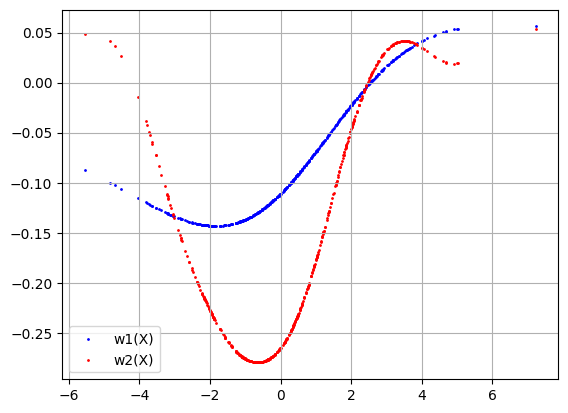

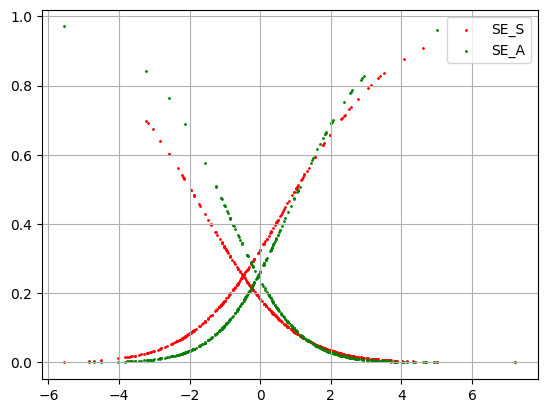

In [64]:
X_arr = np.array(df_merged_val["X1"])

w1x_arr = np.array(df_merged_val["w1(X)"])
w2x_arr = np.array(df_merged_val["w2(X)"])

norm_w2x_arr = w2x_arr / np.trapz(w2x_arr, X_arr)

plt.figure()
plt.scatter(X_arr, w1x_arr, color='blue', s=1, label='w1(X)')
plt.scatter(X_arr, norm_w2x_arr, color='red', s=1, label='w2(X)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
# plt.scatter(X_arr, df_merged_val["SE_Y1"], color='blue', s=1, label="SE_Y1")
plt.scatter(X_arr, df_merged_val["SE_S"], color='red', s=1, label="SE_S")
plt.scatter(X_arr, df_merged_val["SE_A"], color='green', s=1, label="SE_A")
plt.legend()
plt.grid(True)
plt.show()


In [25]:
plt.figure()
plt.scatter(df_merged["X1"], df_merged["hat_SE_Y1"], color='blue', s=1, label="SE_Y1")
plt.legend()
plt.grid(True)
plt.show()

KeyError: 'hat_SE_Y1'

<Figure size 640x480 with 0 Axes>

In [67]:
key = "SE_S"

from sklearn.neural_network import MLPRegressor

X = np.array(df_merged.query("A==1")["X1"]).reshape(-1,1)
y = np.array(df_merged.query("A==1")[key])

model = MLPRegressor(hidden_layer_sizes=(16,), activation="tanh").fit(X, y)

df_merged[f'hat_{key}'] = model.predict(X)

plt.figure()
plt.scatter(df_merged["X1"], df_merged[f"hat_{key}"], color='blue', s=1, label=key)
plt.legend()
plt.grid(True)
plt.show()

ValueError: Length of values (5018) does not match length of index (10000)

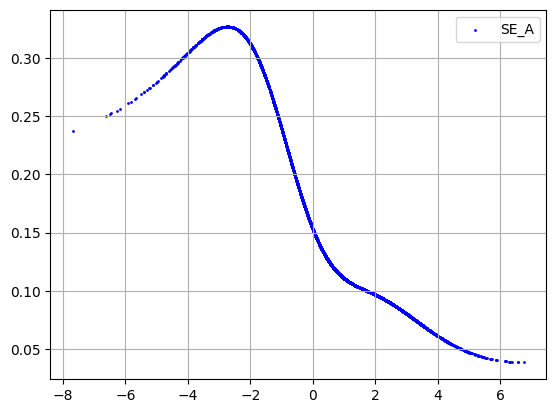

In [52]:
key = "SE_A"

from sklearn.neural_network import MLPRegressor

X = np.array(df_merged.query("A==1")["X1"]).reshape(-1,1)
y = np.array(df_merged.query("A==1")[key])

model = MLPRegressor(hidden_layer_sizes=(16,), activation="tanh").fit(X, y)

df_merged.loc[df_merged.A==1, f'hat_{key}'] = model.predict(X)

plt.figure()
plt.scatter(df_merged["X1"], df_merged[f"hat_{key}"], color='blue', s=1, label=key)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df_merged

In [ ]:
len(model.predict(X))

In [ ]:
df_merged["SE_Y1"]

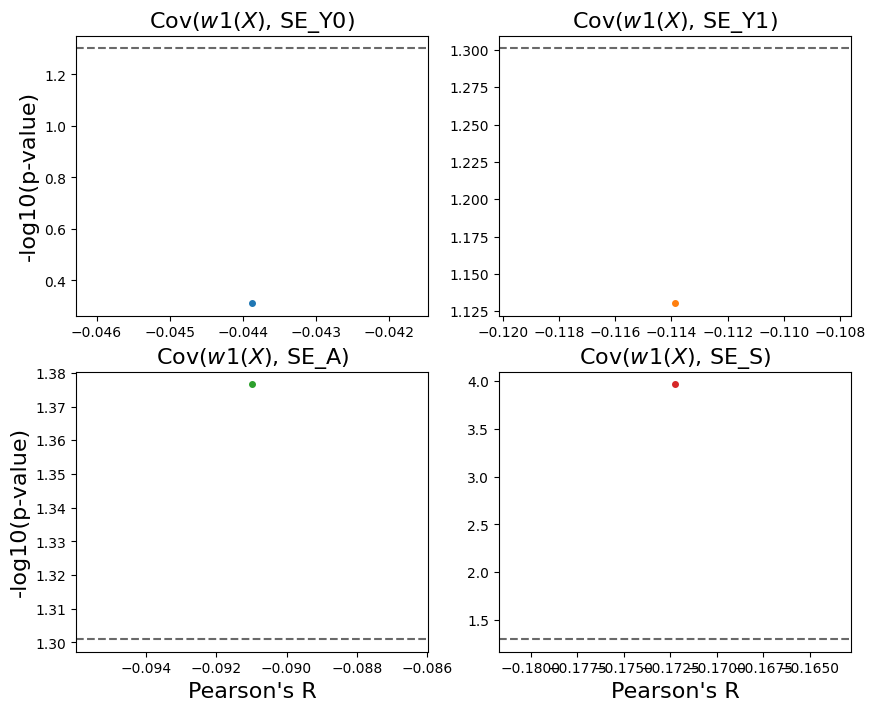

In [68]:
cp = sns.color_palette("tab10")
fig, axs = plt.subplots(2, 2, figsize=(10,8)) 

for idx, key in enumerate(covariances["val1"]):
    i = idx // 2
    j = idx % 2

    axs[i, j].set_title(f"Cov($w1(X)$, {key})", fontsize=16)
    axs[i, j].axhline(y=-np.log10(0.05), color='dimgray', linestyle='--', label='p = 0.05')
    
    arr = np.array(covariances["val1"][key])
    hat_cov = arr[:, 0]
    log_p_val = np.clip(-np.log10(arr[:, 1]), a_min=None, a_max=5)
    axs[i, j].scatter(hat_cov, log_p_val, color=cp[idx], s=16, alpha=1)

axs[0,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_xlabel("Pearson's R", fontsize=16)
axs[1,1].set_xlabel("Pearson's R", fontsize=16)

plt.show()

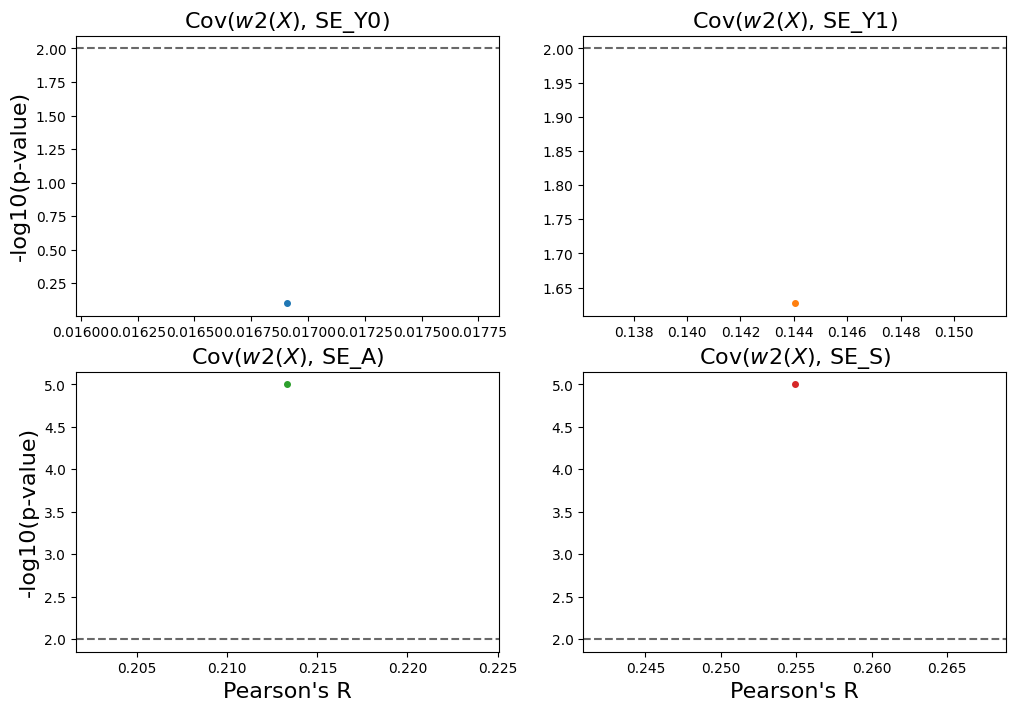

In [69]:
cp = sns.color_palette("tab10")
fig, axs = plt.subplots(2, 2, figsize=(12,8)) 

for idx, key in enumerate(covariances["val2"]):
    i = idx // 2
    j = idx % 2

    axs[i, j].set_title(f"Cov($w2(X)$, {key})", fontsize=16)
    axs[i, j].axhline(y=-np.log10(0.01), color='dimgray', linestyle='--', label='p = 0.05')
    
    arr = abs(np.array(covariances["val2"][key]))
    hat_cov = arr[:, 0]
    log_p_val = np.clip(-np.log10(arr[:, 1]), a_min=None, a_max=5)
    axs[i, j].scatter(hat_cov, log_p_val, color=cp[idx], s=16, alpha=1)

axs[0,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_xlabel("Pearson's R", fontsize=16)
axs[1,1].set_xlabel("Pearson's R", fontsize=16)

plt.show()

In [ ]:
import statsmodels.api as sm

n = len(df_merged_val)
X = df_merged_val['SE_A']  
y = df_merged_val['w2(X)']

X = sm.add_constant(X)  

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

# Extract specific statistics
# coefficients = results.params
# t_statistics = results.tvalues
# p_values = results.pvalues
# r_squared = results.rsquared

# # Display the extracted values
# print("\nCoefficients:")
# print(coefficients)
# print("\nT-statistics:")
# print(t_statistics)
# print("\nP-values:")
# print(p_values)
# print(f"\nR-squared: {r_squared}")


In [ ]:
import statsmodels.api as sm

n = len(df_merged_val)
X = df_merged_val['SE_S']  
y = df_merged_val['w2(X)']

X = sm.add_constant(X)  

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

# Extract specific statistics
coefficients = results.params
t_statistics = results.tvalues
p_values = results.pvalues
r_squared = results.rsquared

# Display the extracted values
print("\nCoefficients:")
print(coefficients)
print("\nT-statistics:")
print(t_statistics)
print("\nP-values:")
print(p_values)
print(f"\nR-squared: {r_squared}")


In [ ]:
plt.figure()
plt.scatter(df_merged_val["X1"], df_merged_val["SE_A"], color='blue', s=2)
plt.scatter(df_merged_val["X1"], df_merged_val["SE_S"], color='red', s=2)
plt.grid(True)
plt.show()